In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Liver_disease_data.csv")
df

,Age,Gender,BMI,AlcoholConsumption,Smoking,GeneticRisk,PhysicalActivity,Diabetes,Hypertension,LiverFunctionTest,Diagnosis
0,58,0,35.857584,17.272828,0,1,0.658940,0,0,42.734240,1
1,71,1,30.732470,2.201266,0,1,1.670557,1,0,67.309822,1
2,48,0,19.971407,18.500944,0,0,9.928308,0,0,63.738956,0
3,34,1,16.615417,12.632870,0,0,5.630129,0,0,64.555873,1
4,62,1,16.065830,1.087815,0,1,3.566218,1,0,77.868689,1
...,...,...,...,...,...,...,...,...,...,...,...
1695,42,0,38.498295,14.384688,0,1,0.992289,0,0,97.933961,1
1696,40,0,27.600094,5.431009,0,0,8.390492,0,0,70.260528,1
1697,38,0,38.730017,6.324302,1,2,9.314222,0,1,56.053370,1
1698,67,0,35.820798,16.899417,0,2,3.224453,0,0,26.300875,1


exploring the dataset

In [2]:
print("columns:", df.columns.tolist())
print("data types:", df.dtypes)
print("missing values:", df.isnull().sum())

columns: ['Age', 'Gender', 'BMI', 'AlcoholConsumption', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'Diabetes', 'Hypertension', 'LiverFunctionTest', 'Diagnosis']
data types: Age                     int64
Gender                  int64
BMI                   float64
AlcoholConsumption    float64
Smoking                 int64
GeneticRisk             int64
PhysicalActivity      float64
Diabetes                int64
Hypertension            int64
LiverFunctionTest     float64
Diagnosis               int64
dtype: object
missing values: Age                   0
Gender                0
BMI                   0
AlcoholConsumption    0
Smoking               0
GeneticRisk           0
PhysicalActivity      0
Diabetes              0
Hypertension          0
LiverFunctionTest     0
Diagnosis             0
dtype: int64


# **Preprocessing**

drop the target column

In [3]:
target = "Diagnosis"
X = df.drop(columns=[target])
y = df[target]

scale the numeric values

In [4]:
from sklearn.preprocessing import StandardScaler

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

encoding categorical columns

In [5]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

categorical_features = X.select_dtypes(include=["object"]).columns


for col in categorical_features:
    if X[col].nunique() == 2:
        le = LabelEncoder()
        X_scaled[col] = le.fit_transform(X[col])
    else:
        X_scaled = pd.get_dummies(X_scaled, columns=[col], drop_first=True)

# **EDA**

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


distribution

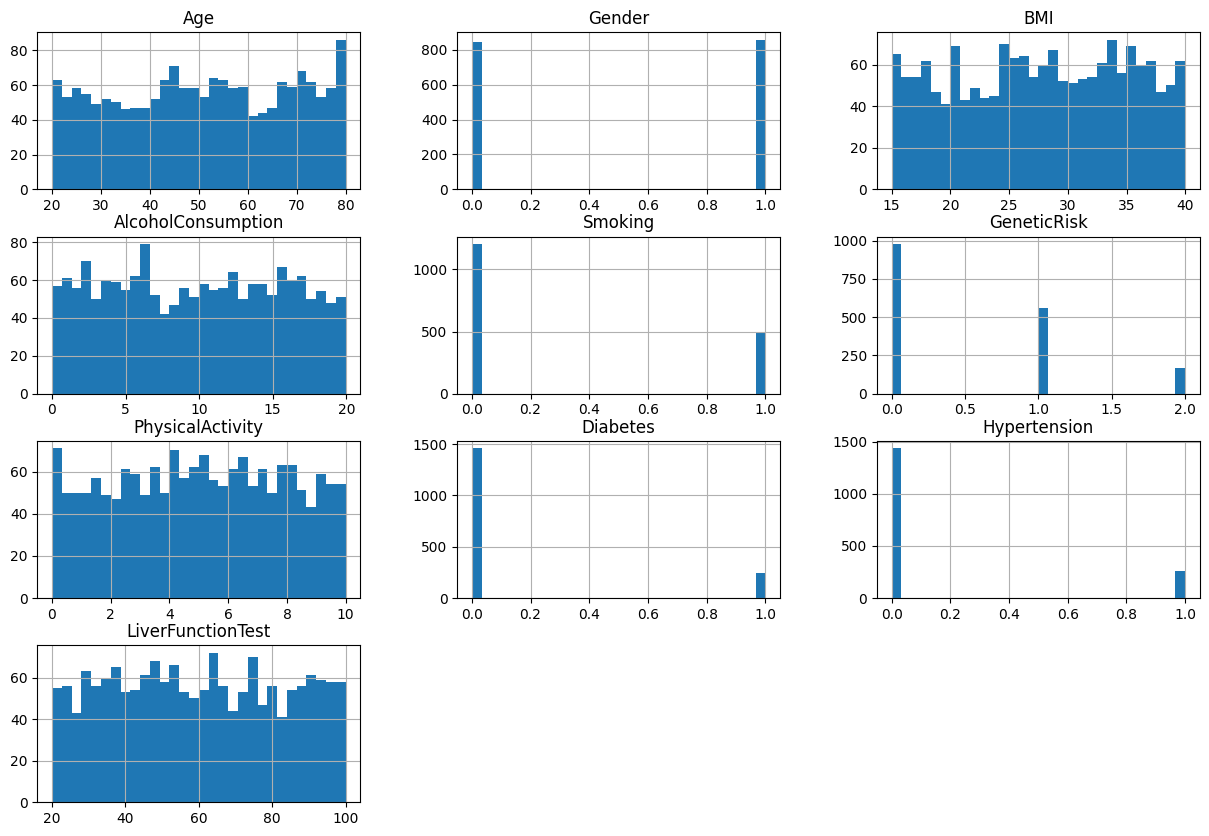

In [7]:
X.hist(figsize=(15,10), bins=30)
plt.show()

boxplots for outliers

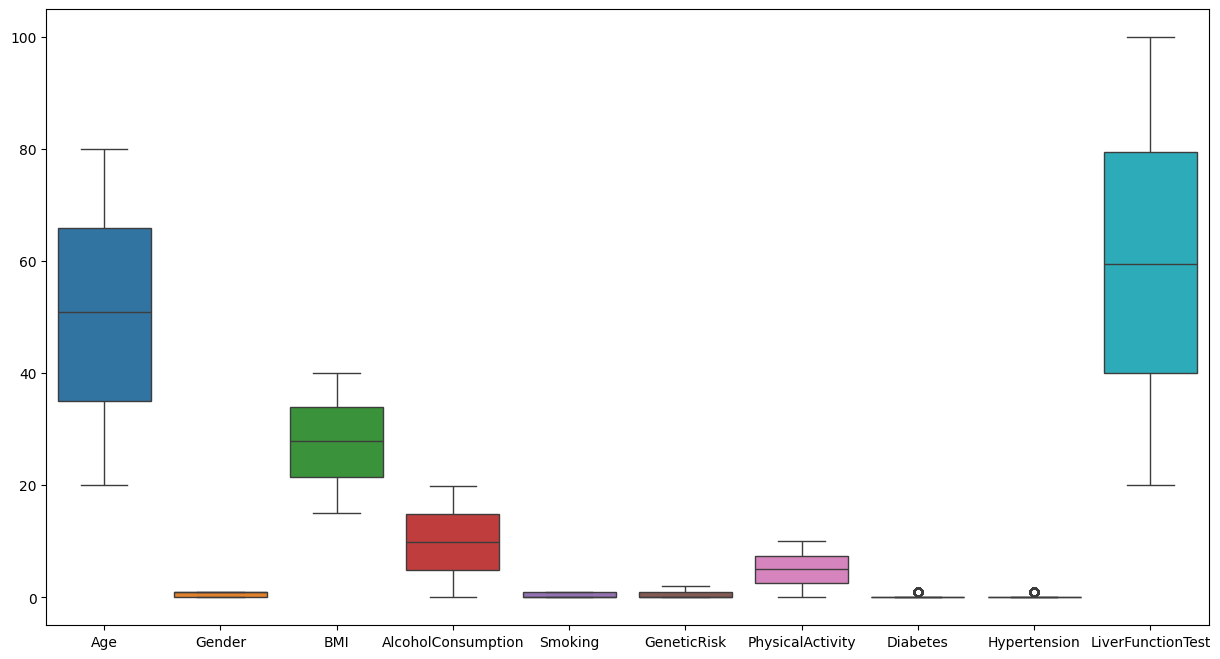

In [8]:
plt.figure(figsize=(15,8))
sns.boxplot(data=X[numeric_features])
plt.show()

scatter plots

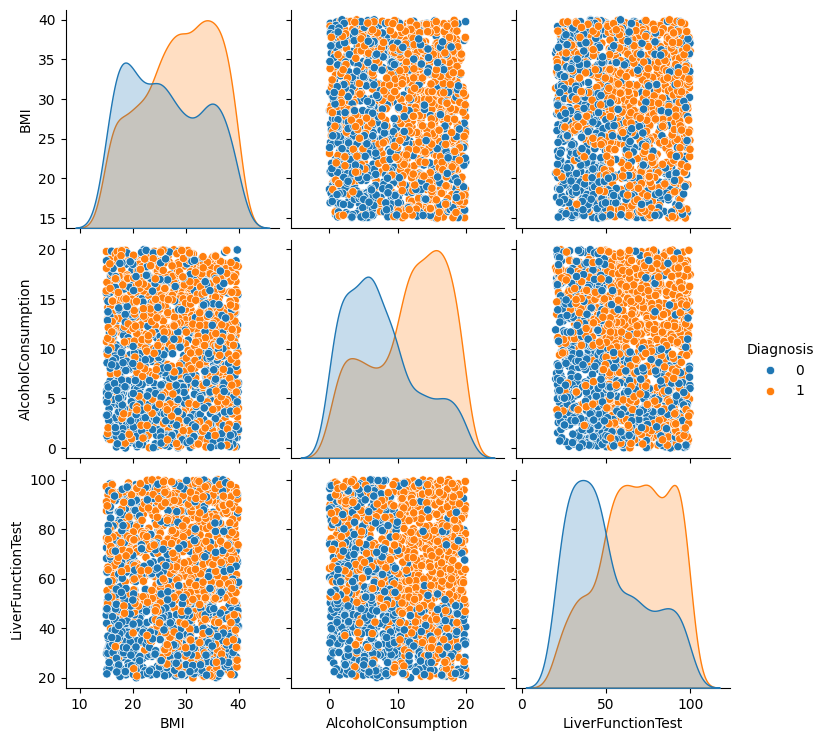

In [9]:
sns.pairplot(df[[ "BMI", "AlcoholConsumption", "LiverFunctionTest", "Diagnosis"]], hue="Diagnosis")
plt.show()

correlation heatmap

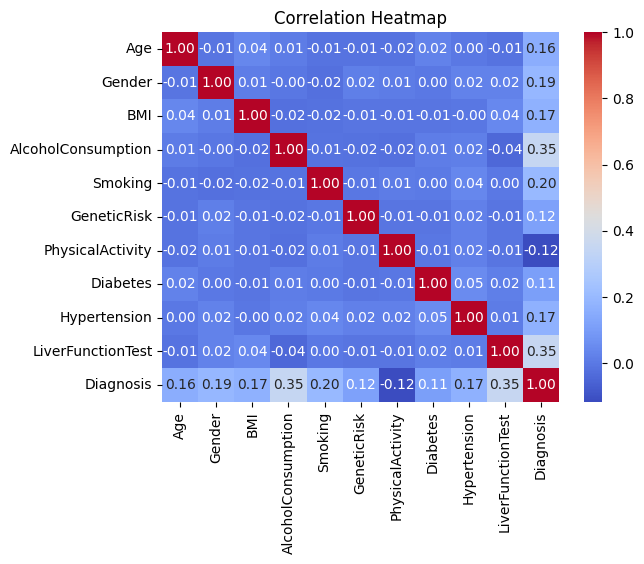

In [10]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

realtionship between feature and the target column(label)

In [11]:
corr_target = df.corr()["Diagnosis"].sort_values(ascending=False)
print("Correlation with Target:", corr_target)

Correlation with Target: Diagnosis             1.000000
LiverFunctionTest     0.354003
AlcoholConsumption    0.349610
Smoking               0.200071
Gender                0.189558
Hypertension          0.170683
BMI                   0.167655
Age                   0.156099
GeneticRisk           0.118292
Diabetes              0.107480
PhysicalActivity     -0.116689
Name: Diagnosis, dtype: float64


no irrelevant feature to be dropped

bar plots for cateforical features

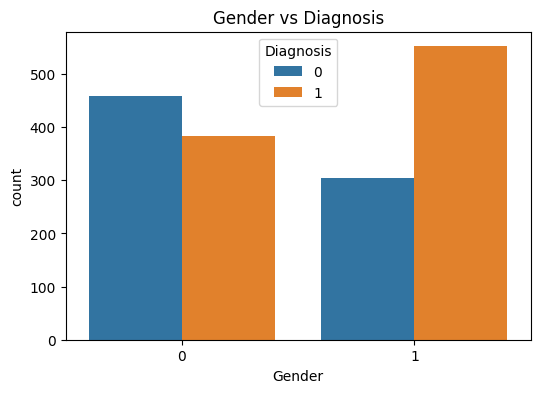

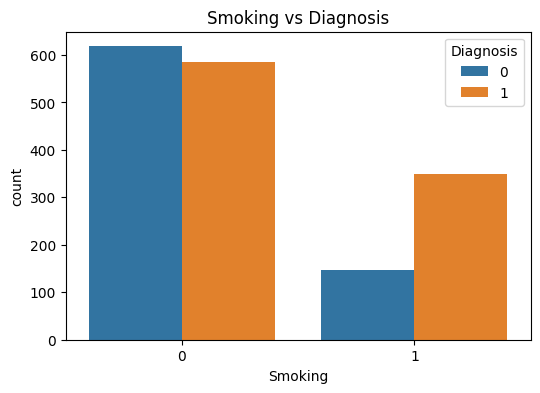

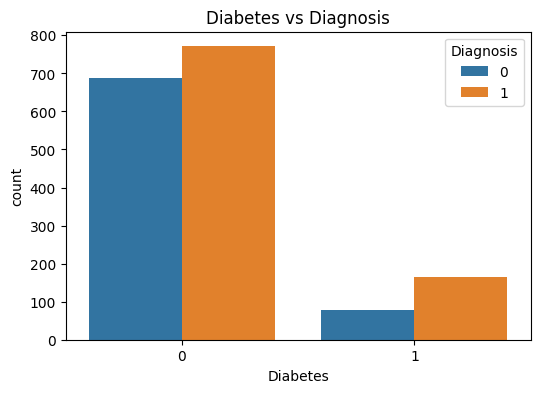

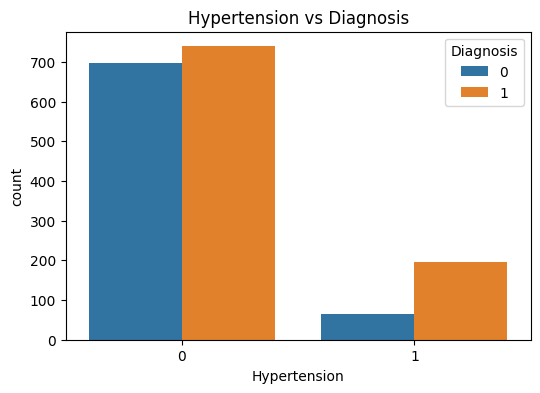

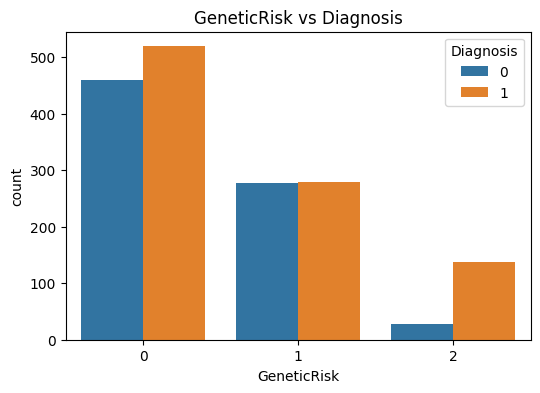

In [12]:
categorical_features = ["Gender", "Smoking", "Diabetes", "Hypertension", "GeneticRisk"]
for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue=target)
    plt.title(f"{col} vs {target}")
    plt.show()

# Splitting the data

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

In [14]:
TARGET = "Diagnosis"

drop target column

In [15]:
y_raw = df[TARGET]
X = df.drop(columns=[TARGET])

train val test (20-20-60)

In [16]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

# **SVM**

In [17]:
from sklearn.svm import SVC

Basic SVM (kernel='rbf', C=1.0, gamma='scale')

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC())  # kernel='rbf', C=1.0, gamma='scale'
])

Hyperparameters

In [20]:
param_svm = {
    "clf__kernel": ["linear", "rbf", "poly"],
    "clf__C": [0.1, 1, 10],
    "clf__gamma": ["scale", "auto"],   # ignored by linear
    "clf__degree": [2, 3],             # used only for poly
}

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "recall": make_scorer(recall_score),
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

GridSearchCV

In [24]:
import time
from sklearn.model_selection import GridSearchCV

t0 = time.time()
grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_svm,
    cv=cv5,
    scoring=scoring,
    refit="recall",          # prioritize Recall (minimize FNR)
    n_jobs=-1,
    return_train_score=True
)
grid_svm.fit(X_train, y_train)
t1 = time.time()

Top 10 combinations (Table)

In [25]:
cv = pd.DataFrame(grid_svm.cv_results_).copy()
cv["FNR"] = 1 - cv["mean_test_recall"]
cols = ["param_clf__kernel","param_clf__C","param_clf__gamma","param_clf__degree",
        "FNR","mean_test_recall","mean_test_accuracy","mean_test_precision","mean_test_f1",
        "mean_train_recall","mean_fit_time","std_fit_time","mean_score_time"]
top10 = (cv[cols]
         .sort_values(by=["FNR","mean_test_accuracy"], ascending=[True, False])
         .head(10).reset_index(drop=True))
top10["FNR"] = top10["FNR"].round(4)
for c in ["mean_test_recall","mean_test_accuracy","mean_test_precision","mean_test_f1","mean_train_recall"]:
    top10[c] = (top10[c]*100).round(2)
top10 = top10.rename(columns={"mean_fit_time":"avg_fit_time_s","std_fit_time":"std_fit_time_s","mean_score_time":"avg_score_time_s"})
top10[["avg_fit_time_s","std_fit_time_s","avg_score_time_s"]] = top10[["avg_fit_time_s","std_fit_time_s","avg_score_time_s"]].round(3)
print("\nTop 10 SVM combos (FNR then Accuracy):")
print(top10.to_string(index=False))


Top 10 SVM combos (FNR then Accuracy):
param_clf__kernel  param_clf__C param_clf__gamma  param_clf__degree    FNR  mean_test_recall  mean_test_accuracy  mean_test_precision  mean_test_f1  mean_train_recall  avg_fit_time_s  std_fit_time_s  avg_score_time_s
             poly           0.1            scale                  2 0.0214             97.86               59.22                57.68         72.57              98.31           0.143           0.032             0.054
             poly           0.1             auto                  2 0.0214             97.86               59.22                57.68         72.57              98.31           0.101           0.017             0.057
              rbf           0.1            scale                  2 0.0889             91.11               80.20                77.15         83.53              92.70           0.133           0.022             0.089
              rbf           0.1             auto                  2 0.0889             91.11

best model

In [26]:
bi = grid_svm.best_index_
print("\nBest SVM params (by recall):", grid_svm.best_params_)
print("Best CV Recall:", round(cv.loc[bi,"mean_test_recall"],4),
      "| CV Train Recall:", round(cv.loc[bi,"mean_train_recall"],4),
      "| Gap (train - cv):", round(cv.loc[bi,"mean_train_recall"]-cv.loc[bi,"mean_test_recall"],4))
print("Avg times — fit:", round(cv.loc[bi,"mean_fit_time"],3),"s (±", round(cv.loc[bi,"std_fit_time"],3),")",
      "| score:", round(cv.loc[bi,"mean_score_time"],3),"s",
      "| Grid total time:", round(t1-t0,2),"s")


Best SVM params (by recall): {'clf__C': 0.1, 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'poly'}
Best CV Recall: 0.9786 | CV Train Recall: 0.9831 | Gap (train - cv): 0.0045
Avg times — fit: 0.143 s (± 0.032 ) | score: 0.054 s | Grid total time: 26.2 s


Validation

In [27]:
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score, f1_score, classification_report

best_svm = grid_svm.best_estimator_
y_val_pred = best_svm.predict(X_val)
cm_val = confusion_matrix(y_val, y_val_pred)
print("\n=== SVM VALIDATION ===")
print("Recall:", round(recall_score(y_val, y_val_pred),4),
      "| FNR:", round(1-recall_score(y_val, y_val_pred),4),
      "| FN:", int(cm_val[1,0]),
      "| Acc:", round(accuracy_score(y_val, y_val_pred),4),
      "| F1:", round(f1_score(y_val, y_val_pred, zero_division=0),4))
print("Confusion Matrix:\n", cm_val)
print("Classification Report:\n", classification_report(y_val, y_val_pred))


=== SVM VALIDATION ===
Recall: 0.9465 | FNR: 0.0535 | FN: 10 | Acc: 0.65 | F1: 0.7484
Confusion Matrix:
 [[ 44 109]
 [ 10 177]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.29      0.43       153
           1       0.62      0.95      0.75       187

    accuracy                           0.65       340
   macro avg       0.72      0.62      0.59       340
weighted avg       0.71      0.65      0.60       340



Test

In [28]:
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score, f1_score, classification_report

y_test_pred = best_svm.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)
print("\n=== SVM TEST (FINAL) ===")
print("Recall:", round(recall_score(y_test, y_test_pred),4),
      "| FNR:", round(1-recall_score(y_test, y_test_pred),4),
      "| FN:", int(cm_test[1,0]),
      "| Acc:", round(accuracy_score(y_test, y_test_pred),4),
      "| F1:", round(f1_score(y_test, y_test_pred, zero_division=0),4))
print("Confusion Matrix:\n", cm_test)
print("Classification Report:\n", classification_report(y_test, y_test_pred))


=== SVM TEST (FINAL) ===
Recall: 0.9572 | FNR: 0.0428 | FN: 8 | Acc: 0.6353 | F1: 0.7427
Confusion Matrix:
 [[ 37 116]
 [  8 179]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.24      0.37       153
           1       0.61      0.96      0.74       187

    accuracy                           0.64       340
   macro avg       0.71      0.60      0.56       340
weighted avg       0.70      0.64      0.58       340



#Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

basic LR

In [30]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

Hyperparameters

In [31]:
param_lr = [
    {"clf__solver": ["lbfgs"],     "clf__penalty": ["l2"],       "clf__C": [0.1, 1, 10]},
    {"clf__solver": ["liblinear"], "clf__penalty": ["l1","l2"],  "clf__C": [0.1, 1, 10]},
]

GridSearchCV

In [32]:
t0 = time.time()
grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_lr,
    cv=cv5,
    scoring=scoring,
    refit="recall",
    n_jobs=-1,
    return_train_score=True
)
grid_lr.fit(X_train, y_train)
t1 = time.time()

Top 10 combinations (table)

In [33]:
cv = pd.DataFrame(grid_lr.cv_results_).copy()
cv["FNR"] = 1 - cv["mean_test_recall"]
cols = ["param_clf__solver","param_clf__penalty","param_clf__C",
        "FNR","mean_test_recall","mean_test_accuracy","mean_test_precision","mean_test_f1",
        "mean_train_recall","mean_fit_time","std_fit_time","mean_score_time"]
top10 = (cv[cols]
         .sort_values(by=["FNR","mean_test_accuracy"], ascending=[True, False])
         .head(10).reset_index(drop=True))
top10["FNR"] = top10["FNR"].round(4)
for c in ["mean_test_recall","mean_test_accuracy","mean_test_precision","mean_test_f1","mean_train_recall"]:
    top10[c] = (top10[c]*100).round(2)
top10 = top10.rename(columns={"mean_fit_time":"avg_fit_time_s","std_fit_time":"std_fit_time_s","mean_score_time":"avg_score_time_s"})
top10[["avg_fit_time_s","std_fit_time_s","avg_score_time_s"]] = top10[["avg_fit_time_s","std_fit_time_s","avg_score_time_s"]].round(3)
print("\nTop 10 LR combos (FNR then Accuracy):")
print(top10.to_string(index=False))


Top 10 LR combos (FNR then Accuracy):
param_clf__solver param_clf__penalty  param_clf__C    FNR  mean_test_recall  mean_test_accuracy  mean_test_precision  mean_test_f1  mean_train_recall  avg_fit_time_s  std_fit_time_s  avg_score_time_s
            lbfgs                 l2           0.1 0.1406             85.94               83.43                84.46         85.13              87.37           0.014           0.003             0.024
        liblinear                 l1          10.0 0.1424             85.76               83.82                85.17         85.40              86.83           0.014           0.005             0.032
            lbfgs                 l2           1.0 0.1424             85.76               83.73                85.03         85.33              86.88           0.017           0.007             0.027
        liblinear                 l1           1.0 0.1442             85.58               83.63                85.01         85.23              86.52           0

best LR model

In [34]:
bi = grid_lr.best_index_
print("\nBest LR params (by recall):", grid_lr.best_params_)
print("Best CV Recall:", round(cv.loc[bi,"mean_test_recall"],4),
      "| CV Train Recall:", round(cv.loc[bi,"mean_train_recall"],4),
      "| Gap (train - cv):", round(cv.loc[bi,"mean_train_recall"]-cv.loc[bi,"mean_test_recall"],4))
print("Avg times — fit:", round(cv.loc[bi,"mean_fit_time"],3),"s (±", round(cv.loc[bi,"std_fit_time"],3),")",
      "| score:", round(cv.loc[bi,"mean_score_time"],3),"s",
      "| Grid total time:", round(t1-t0,2),"s")


Best LR params (by recall): {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV Recall: 0.8594 | CV Train Recall: 0.8737 | Gap (train - cv): 0.0143
Avg times — fit: 0.014 s (± 0.003 ) | score: 0.024 s | Grid total time: 1.93 s


validation

In [38]:
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score, f1_score, classification_report

best_lr = grid_lr.best_estimator_
y_val_pred = best_lr.predict(X_val)
cm_val = confusion_matrix(y_val, y_val_pred)
print("\n=== LR VALIDATION ===")
print("Recall:", round(recall_score(y_val, y_val_pred),4),
      "| FNR:", round(1-recall_score(y_val, y_val_pred),4),
      "| FN:", int(cm_val[1,0]),
      "| Acc:", round(accuracy_score(y_val, y_val_pred),4),
      "| F1:", round(f1_score(y_val, y_val_pred, zero_division=0),4))
print("Confusion Matrix:\n", cm_val)
print("Classification Report:\n", classification_report(y_val, y_val_pred))


=== LR VALIDATION ===
Recall: 0.7914 | FNR: 0.2086 | FN: 39 | Acc: 0.7853 | F1: 0.8022
Confusion Matrix:
 [[119  34]
 [ 39 148]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.78      0.77       153
           1       0.81      0.79      0.80       187

    accuracy                           0.79       340
   macro avg       0.78      0.78      0.78       340
weighted avg       0.79      0.79      0.79       340



test

In [39]:
y_test_pred = best_lr.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)
print("\n=== LR TEST (FINAL) ===")
print("Recall:", round(recall_score(y_test, y_test_pred),4),
      "| FNR:", round(1-recall_score(y_test, y_test_pred),4),
      "| FN:", int(cm_test[1,0]),
      "| Acc:", round(accuracy_score(y_test, y_test_pred),4),
      "| F1:", round(f1_score(y_test, y_test_pred, zero_division=0),4))
print("Confusion Matrix:\n", cm_test)
print("Classification Report:\n", classification_report(y_test, y_test_pred))


=== LR TEST (FINAL) ===
Recall: 0.8289 | FNR: 0.1711 | FN: 32 | Acc: 0.8235 | F1: 0.8378
Confusion Matrix:
 [[125  28]
 [ 32 155]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.82      0.81       153
           1       0.85      0.83      0.84       187

    accuracy                           0.82       340
   macro avg       0.82      0.82      0.82       340
weighted avg       0.82      0.82      0.82       340



# Decision Tree

In [40]:
from sklearn.tree import DecisionTreeClassifier

basic decision tree

In [41]:
dt = DecisionTreeClassifier(random_state=42)

Hyperparameters

In [42]:
param_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

GridSearchCV

In [43]:
t0 = time.time()
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_dt,
    cv=cv5,
    scoring=scoring,
    refit="recall",
    n_jobs=-1,
    return_train_score=True
)
grid_dt.fit(X_train, y_train)
t1 = time.time()

Top 10 combinations (table)

In [44]:
cv = pd.DataFrame(grid_dt.cv_results_).copy()
cv["FNR"] = 1 - cv["mean_test_recall"]
cols = ["param_criterion","param_max_depth","param_min_samples_split","param_min_samples_leaf",
        "FNR","mean_test_recall","mean_test_accuracy","mean_test_precision","mean_test_f1",
        "mean_train_recall","mean_fit_time","std_fit_time","mean_score_time"]
top10 = (cv[cols]
         .sort_values(by=["FNR","mean_test_accuracy"], ascending=[True, False])
         .head(10).reset_index(drop=True))
top10["FNR"] = top10["FNR"].round(4)
for c in ["mean_test_recall","mean_test_accuracy","mean_test_precision","mean_test_f1","mean_train_recall"]:
    top10[c] = (top10[c]*100).round(2)
top10 = top10.rename(columns={"mean_fit_time":"avg_fit_time_s","std_fit_time":"std_fit_time_s","mean_score_time":"avg_score_time_s"})
top10[["avg_fit_time_s","std_fit_time_s","avg_score_time_s"]] = top10[["avg_fit_time_s","std_fit_time_s","avg_score_time_s"]].round(3)
print("\nTop 10 DT combos (FNR then Accuracy):")
print(top10.to_string(index=False))


Top 10 DT combos (FNR then Accuracy):
param_criterion param_max_depth  param_min_samples_split  param_min_samples_leaf    FNR  mean_test_recall  mean_test_accuracy  mean_test_precision  mean_test_f1  mean_train_recall  avg_fit_time_s  std_fit_time_s  avg_score_time_s
           gini               5                        2                       2 0.1815             81.85               81.37                84.03         82.89              87.23           0.009           0.000             0.015
           gini               5                        5                       2 0.1815             81.85               81.37                84.03         82.89              87.23           0.009           0.000             0.014
        entropy               5                        2                       4 0.1816             81.84               80.88                83.29         82.51              87.37           0.010           0.000             0.015
        entropy               5          

best model

In [45]:
bi = grid_dt.best_index_
print("\nBest DT params (by recall):", grid_dt.best_params_)
print("Best CV Recall:", round(cv.loc[bi,"mean_test_recall"],4),
      "| CV Train Recall:", round(cv.loc[bi,"mean_train_recall"],4),
      "| Gap (train - cv):", round(cv.loc[bi,"mean_train_recall"]-cv.loc[bi,"mean_test_recall"],4))
print("Avg times — fit:", round(cv.loc[bi,"mean_fit_time"],3),"s (±", round(cv.loc[bi,"std_fit_time"],3),")",
      "| score:", round(cv.loc[bi,"mean_score_time"],3),"s",
      "| Grid total time:", round(t1-t0,2),"s")


Best DT params (by recall): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV Recall: 0.8185 | CV Train Recall: 0.8723 | Gap (train - cv): 0.0538
Avg times — fit: 0.009 s (± 0.0 ) | score: 0.015 s | Grid total time: 14.94 s


validaiton

In [48]:
y_val_pred = grid_dt.best_estimator_.predict(X_val)
cm_val = confusion_matrix(y_val, y_val_pred)
print("\n=== DT VALIDATION ===")
print("Recall:", round(recall_score(y_val, y_val_pred),4),
      "| FNR:", round(1-recall_score(y_val, y_val_pred),4),
      "| FN:", int(cm_val[1,0]),
      "| Acc:", round(accuracy_score(y_val, y_val_pred),4),
      "| F1:", round(f1_score(y_val, y_val_pred, zero_division=0),4))
print("Confusion Matrix:\n", cm_val)
print("Classification Report:\n", classification_report(y_val, y_val_pred))


=== DT VALIDATION ===
Recall: 0.8396 | FNR: 0.1604 | FN: 30 | Acc: 0.8235 | F1: 0.8396
Confusion Matrix:
 [[123  30]
 [ 30 157]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80       153
           1       0.84      0.84      0.84       187

    accuracy                           0.82       340
   macro avg       0.82      0.82      0.82       340
weighted avg       0.82      0.82      0.82       340



test

In [51]:
y_test_pred = grid_dt.best_estimator_.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)
print("\n=== DT TEST (FINAL) ===")
print("Recall:", round(recall_score(y_test, y_test_pred),4),
      "| FNR:", round(1-recall_score(y_test, y_test_pred),4),
      "| FN:", int(cm_test[1,0]),
      "| Acc:", round(accuracy_score(y_test, y_test_pred),4),
      "| F1:", round(f1_score(y_test, y_test_pred, zero_division=0),4))
print("Confusion Matrix:\n", cm_test)
print("Classification Report:\n", classification_report(y_test, y_test_pred))


=== DT TEST (FINAL) ===
Recall: 0.8128 | FNR: 0.1872 | FN: 35 | Acc: 0.8324 | F1: 0.8421
Confusion Matrix:
 [[131  22]
 [ 35 152]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.86      0.82       153
           1       0.87      0.81      0.84       187

    accuracy                           0.83       340
   macro avg       0.83      0.83      0.83       340
weighted avg       0.84      0.83      0.83       340



# Random Forest Classifier

In [52]:
from sklearn.ensemble import RandomForestClassifier

basic random fores model

In [53]:
rf = RandomForestClassifier(random_state=42)

Hyperparameters

In [54]:
param_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 6, 7],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

GridSearchCV

In [55]:
t0 = time.time()
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_rf,
    cv=cv5,
    scoring=scoring,
    refit="recall",
    n_jobs=-1,
    return_train_score=True
)
grid_rf.fit(X_train, y_train)
t1 = time.time()

top 10 combinations

In [56]:
cv = pd.DataFrame(grid_rf.cv_results_).copy()
cv["FNR"] = 1 - cv["mean_test_recall"]
cols = ["param_n_estimators","param_max_depth","param_min_samples_split","param_min_samples_leaf","param_max_features",
        "FNR","mean_test_recall","mean_test_accuracy","mean_test_precision","mean_test_f1",
        "mean_train_recall","mean_fit_time","std_fit_time","mean_score_time"]
top10 = (cv[cols]
         .sort_values(by=["FNR","mean_test_accuracy"], ascending=[True, False])
         .head(10).reset_index(drop=True))
top10["FNR"] = top10["FNR"].round(4)
for c in ["mean_test_recall","mean_test_accuracy","mean_test_precision","mean_test_f1","mean_train_recall"]:
    top10[c] = (top10[c]*100).round(2)
top10 = top10.rename(columns={"mean_fit_time":"avg_fit_time_s","std_fit_time":"std_fit_time_s","mean_score_time":"avg_score_time_s"})
top10[["avg_fit_time_s","std_fit_time_s","avg_score_time_s"]] = top10[["avg_fit_time_s","std_fit_time_s","avg_score_time_s"]].round(3)
print("\nTop 10 RF combos (FNR then Accuracy):")
print(top10.to_string(index=False))


Top 10 RF combos (FNR then Accuracy):
 param_n_estimators param_max_depth  param_min_samples_split  param_min_samples_leaf param_max_features    FNR  mean_test_recall  mean_test_accuracy  mean_test_precision  mean_test_f1  mean_train_recall  avg_fit_time_s  std_fit_time_s  avg_score_time_s
                200            None                        2                       2               sqrt 0.0962             90.38               88.24                88.54         89.42              98.84           0.828           0.068             0.056
                200            None                        2                       2               log2 0.0962             90.38               88.24                88.54         89.42              98.84           0.978           0.220             0.059
                200              20                        2                       2               sqrt 0.0962             90.38               88.24                88.54         89.42              98.84

best model

In [57]:
bi = grid_rf.best_index_
print("\nBest RF params (by recall):", grid_rf.best_params_)
print("Best CV Recall:", round(cv.loc[bi,"mean_test_recall"],4),
      "| CV Train Recall:", round(cv.loc[bi,"mean_train_recall"],4),
      "| Gap (train - cv):", round(cv.loc[bi,"mean_train_recall"]-cv.loc[bi,"mean_test_recall"],4))
print("Avg times — fit:", round(cv.loc[bi,"mean_fit_time"],3),"s (±", round(cv.loc[bi,"std_fit_time"],3),")",
      "| score:", round(cv.loc[bi,"mean_score_time"],3),"s",
      "| Grid total time:", round(t1-t0,2),"s")


Best RF params (by recall): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Recall: 0.9038 | CV Train Recall: 0.9884 | Gap (train - cv): 0.0846
Avg times — fit: 0.828 s (± 0.068 ) | score: 0.056 s | Grid total time: 421.83 s


validation

In [60]:
y_val_pred = grid_rf.best_estimator_.predict(X_val)
cm_val = confusion_matrix(y_val, y_val_pred)
print("\n=== RF VALIDATION ===")
print("Recall:", round(recall_score(y_val, y_val_pred),4),
      "| FNR:", round(1-recall_score(y_val, y_val_pred),4),
      "| FN:", int(cm_val[1,0]),
      "| Acc:", round(accuracy_score(y_val, y_val_pred),4),
      "| F1:", round(f1_score(y_val, y_val_pred, zero_division=0),4))
print("Confusion Matrix:\n", cm_val)
print("Classification Report:\n", classification_report(y_val, y_val_pred))


=== RF VALIDATION ===
Recall: 0.8717 | FNR: 0.1283 | FN: 24 | Acc: 0.8882 | F1: 0.8956
Confusion Matrix:
 [[139  14]
 [ 24 163]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88       153
           1       0.92      0.87      0.90       187

    accuracy                           0.89       340
   macro avg       0.89      0.89      0.89       340
weighted avg       0.89      0.89      0.89       340



test

In [61]:
y_test_pred = grid_rf.best_estimator_.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)
print("\n=== RF TEST (FINAL) ===")
print("Recall:", round(recall_score(y_test, y_test_pred),4),
      "| FNR:", round(1-recall_score(y_test, y_test_pred),4),
      "| FN:", int(cm_test[1,0]),
      "| Acc:", round(accuracy_score(y_test, y_test_pred),4),
      "| F1:", round(f1_score(y_test, y_test_pred, zero_division=0),4))
print("Confusion Matrix:\n", cm_test)
print("Classification Report:\n", classification_report(y_test, y_test_pred))


=== RF TEST (FINAL) ===
Recall: 0.861 | FNR: 0.139 | FN: 26 | Acc: 0.8971 | F1: 0.902
Confusion Matrix:
 [[144   9]
 [ 26 161]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.89       153
           1       0.95      0.86      0.90       187

    accuracy                           0.90       340
   macro avg       0.90      0.90      0.90       340
weighted avg       0.90      0.90      0.90       340



# Gradient Boosting

In [62]:
from sklearn.ensemble import GradientBoostingClassifier

basic GB

In [63]:
gb = GradientBoostingClassifier(random_state=42)

Hyperparameters

In [64]:
param_gb = {
    "n_estimators":  [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth":     [3, 5],
}

GridSearchCV

In [65]:
t0 = time.time()
grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_gb,
    cv=cv5,
    scoring=scoring,
    refit="recall",
    n_jobs=-1,
    return_train_score=True
)
grid_gb.fit(X_train, y_train)
t1 = time.time()

top 10 combinations

In [66]:
cv = pd.DataFrame(grid_gb.cv_results_).copy()
cv["FNR"] = 1 - cv["mean_test_recall"]
cols = ["param_n_estimators","param_learning_rate","param_max_depth",
        "FNR","mean_test_recall","mean_test_accuracy","mean_test_precision","mean_test_f1",
        "mean_train_recall","mean_fit_time","std_fit_time","mean_score_time"]
top10 = (cv[cols]
         .sort_values(by=["FNR","mean_test_accuracy"], ascending=[True, False])
         .head(10).reset_index(drop=True))
top10["FNR"] = top10["FNR"].round(4)
for c in ["mean_test_recall","mean_test_accuracy","mean_test_precision","mean_test_f1","mean_train_recall"]:
    top10[c] = (top10[c]*100).round(2)
top10 = top10.rename(columns={"mean_fit_time":"avg_fit_time_s","std_fit_time":"std_fit_time_s","mean_score_time":"avg_score_time_s"})
top10[["avg_fit_time_s","std_fit_time_s","avg_score_time_s"]] = top10[["avg_fit_time_s","std_fit_time_s","avg_score_time_s"]].round(3)
print("\nTop 10 GB combos (FNR then Accuracy):")
print(top10.to_string(index=False))


Top 10 GB combos (FNR then Accuracy):
 param_n_estimators  param_learning_rate  param_max_depth    FNR  mean_test_recall  mean_test_accuracy  mean_test_precision  mean_test_f1  mean_train_recall  avg_fit_time_s  std_fit_time_s  avg_score_time_s
                100                 0.10                3 0.0873             91.27               89.41                89.67         90.46              98.04           0.465           0.016             0.015
                200                 0.05                3 0.0927             90.73               89.22                89.79         90.24              98.09           1.479           0.152             0.025
                100                 0.20                3 0.0944             90.56               89.51                90.42         90.46              99.47           0.467           0.015             0.015
                100                 0.05                3 0.1033             89.67               88.14                88.90         8

best model

In [67]:
bi = grid_gb.best_index_
print("\nBest GB params (by recall):", grid_gb.best_params_)
print("Best CV Recall:", round(cv.loc[bi,"mean_test_recall"],4),
      "| CV Train Recall:", round(cv.loc[bi,"mean_train_recall"],4),
      "| Gap (train - cv):", round(cv.loc[bi,"mean_train_recall"]-cv.loc[bi,"mean_test_recall"],4))
print("Avg times — fit:", round(cv.loc[bi,"mean_fit_time"],3),"s (±", round(cv.loc[bi,"std_fit_time"],3),")",
      "| score:", round(cv.loc[bi,"mean_score_time"],3),"s",
      "| Grid total time:", round(t1-t0,2),"s")


Best GB params (by recall): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV Recall: 0.9127 | CV Train Recall: 0.9804 | Gap (train - cv): 0.0677
Avg times — fit: 0.465 s (± 0.016 ) | score: 0.015 s | Grid total time: 38.3 s


validation

In [68]:
y_val_pred = grid_gb.best_estimator_.predict(X_val)
cm_val = confusion_matrix(y_val, y_val_pred)
print("\n=== GB VALIDATION ===")
print("Recall:", round(recall_score(y_val, y_val_pred),4),
      "| FNR:", round(1-recall_score(y_val, y_val_pred),4),
      "| FN:", int(cm_val[1,0]),
      "| Acc:", round(accuracy_score(y_val, y_val_pred),4),
      "| F1:", round(f1_score(y_val, y_val_pred, zero_division=0),4))
print("Confusion Matrix:\n", cm_val)
print("Classification Report:\n", classification_report(y_val, y_val_pred))


=== GB VALIDATION ===
Recall: 0.8877 | FNR: 0.1123 | FN: 21 | Acc: 0.8912 | F1: 0.8997
Confusion Matrix:
 [[137  16]
 [ 21 166]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.88       153
           1       0.91      0.89      0.90       187

    accuracy                           0.89       340
   macro avg       0.89      0.89      0.89       340
weighted avg       0.89      0.89      0.89       340



test

In [69]:
y_test_pred = grid_gb.best_estimator_.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)
print("\n=== GB TEST (FINAL) ===")
print("Recall:", round(recall_score(y_test, y_test_pred),4),
      "| FNR:", round(1-recall_score(y_test, y_test_pred),4),
      "| FN:", int(cm_test[1,0]),
      "| Acc:", round(accuracy_score(y_test, y_test_pred),4),
      "| F1:", round(f1_score(y_test, y_test_pred, zero_division=0),4))
print("Confusion Matrix:\n", cm_test)
print("Classification Report:\n", classification_report(y_test, y_test_pred))


=== GB TEST (FINAL) ===
Recall: 0.861 | FNR: 0.139 | FN: 26 | Acc: 0.8882 | F1: 0.8944
Confusion Matrix:
 [[141  12]
 [ 26 161]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.88       153
           1       0.93      0.86      0.89       187

    accuracy                           0.89       340
   macro avg       0.89      0.89      0.89       340
weighted avg       0.89      0.89      0.89       340

